# Confidence-Aware Scoring Analysis

This notebook analyzes the logprobs CSVs produced by the scoring notebooks.


Related notebooks:
- `LogProbsOcsai1.ipynb` (trained model scoring)
- `LogProbsGPT4o.ipynb` (vanilla model scoring)


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

tqdm.pandas()

data_dir = Path('../../data')

# Analysis

## Prep Data

In [6]:
collector = []
id_vars = ['run','type', 'item', 'response', 'target']

for model in ['ocsai-babbage2', 'ocsai-davinci2', 'ocsai-chatgpt', 'gpt-4o', 'gpt-4o-mini', 'gpt-4-1', 'gpt-4-1-mini']:
    df = pd.read_csv(data_dir / 'results/logprobs' / f'logprobs_{model}_ocsai1.csv')
    if model in ['gpt-4-1', 'gpt-4-1-mini']:
        df['run'] = model.replace('4-1', '4.1')
    else:
        df['run'] = model

    # when an item doesn't have a score for the n*th contributor
    # (e.g. looking at top_logprobs=5 but only 4 are provided), 
    # use the previous slots score.

    max_contributors = max([int(c.split('_')[1]) for c in df.columns if c.startswith('score')])
    for i in range(1, max_contributors+1):
        if (i - 1) <= 0:
            continue
        for cat in ['score', 'confidence']:
            prev, col = f'{cat}_{i-1}', f'{cat}_{i}'
            df.loc[df[col].isna(), col] = df.loc[df[col].isna(), prev]

    collector.append(df)
df = pd.concat(collector)

scores_long = df.melt(id_vars=id_vars,
        value_vars=[c for c in df.columns if c.startswith('score_')],
        var_name='contributors',
        value_name='score')

confidences_long = df.melt(id_vars=id_vars,
        value_vars=[c for c in df.columns if c.startswith('confidence_')],
        var_name='contributors',
        value_name='confidence')

scores_long.contributors = scores_long.contributors.str.extract(r'(\d+)').astype(int)
confidences_long.contributors = confidences_long.contributors.str.extract(r'(\d+)').astype(int)

long = scores_long.merge(confidences_long, on=id_vars + ['contributors']).dropna()
# for fairness, keep same precision
long['score'] = long['score'].round(1)

display(long.dropna()['run'].value_counts())
long.sample(5)

run
ocsai-chatgpt     60600
gpt-4o            60600
gpt-4o-mini       60600
gpt-4.1           60600
gpt-4.1-mini      60600
ocsai-babbage2    15150
ocsai-davinci2    15150
Name: count, dtype: int64

,run,type,item,response,target,contributors,score,confidence
416226,gpt-4o-mini,uses,lightbulb,You can make it light up with different things.,1.7,9,1.3,0.999560
124944,gpt-4.1-mini,uses,rope,fuse,2.1,10,3.2,0.616628
127235,gpt-4.1-mini,uses,brick,Ballast,2.7,10,2.7,0.823802
74114,gpt-4o,uses,knife,clean underneath nails,1.2,4,1.7,0.454932
96150,gpt-4o,uses,box,cake holder,1.3,5,1.9,0.629983


In [7]:
# calculate RMSE and Pearson r for target vs score, by group
def evaluate(x):
    r = pearsonr(x['target'], x['score'])[0] # the second item is p-value, which at this scale doesn't need reporting (since it's only not significant when r is very, very low)
    rmse = np.sqrt(mean_squared_error(x['target'], x['score']))
    n = len(x)
    return pd.Series({'r': np.round(r, 3), 'RMSE':np.round(rmse,4), 'n': n})

## Weighted Measure Eval

In [8]:
evaluated = long.dropna().groupby(['run', 'contributors'])[['target', 'score']].apply(evaluate)
display(evaluated.head(40))
evaluated.iloc[40:]

r    RMSE       n
run          contributors                       
gpt-4.1      1             0.628  0.7257  3030.0
             2             0.637  0.7136  3030.0
             3             0.637  0.7142  3030.0
             4             0.637  0.7131  3030.0
             5             0.637  0.7131  3030.0
             6             0.638  0.7130  3030.0
             7             0.638  0.7128  3030.0
             8             0.638  0.7129  3030.0
             9             0.637  0.7132  3030.0
             10            0.638  0.7128  3030.0
             11            0.638  0.7124  3030.0
             12            0.638  0.7127  3030.0
             13            0.638  0.7123  3030.0
             14            0.638  0.7122  3030.0
             15            0.638  0.7120  3030.0
             16            0.638  0.7120  3030.0
             17            0.638  0.7121  3030.0
             18            0.638  0.7124  3030.0
             19            0.638  0.7124  3030.0
             20            0.638  0.7125  3030.0
gpt-4.1-mini 1             0.493  1.0534  3030.0
             2             0.497  1.0300  3030.0
             3             0.502  1.0226  3030.0
             4             0.502  1.0185  3030.0
             5             0.503  1.0149  3030.0
             6             0.504  1.0114  3030.0
             7             0.505  1.0089  3030.0
             8             0.506  1.0066  3030.0
             9             0.507  1.0054  3030.0
             10            0.507  1.0033  3030.0
             11            0.507  1.0026  3030.0
             12            0.508  1.0007  3030.0
             13            0.509  0.9994  3030.0
             14            0.509  0.9983  3030.0
             15            0.509  0.9975  3030.0
             16            0.509  0.9972  3030.0
             17            0.510  0.9964  3030.0
             18            0.509  0.9962  3030.0
             19            0.510  0.9954  3030.0
             20            0.510  0.9949  3030.0

r    RMSE       n
run            contributors                       
gpt-4o         1             0.607  0.7656  3030.0
               2             0.618  0.7497  3030.0
               3             0.620  0.7451  3030.0
               4             0.621  0.7404  3030.0
               5             0.622  0.7381  3030.0
...                            ...     ...     ...
ocsai-davinci2 1             0.774  0.5653  3030.0
               2             0.788  0.5421  3030.0
               3             0.794  0.5310  3030.0
               4             0.798  0.5238  3030.0
               5             0.799  0.5210  3030.0

[70 rows x 3 columns]

In [9]:
# Formatted for Paper
x = evaluated.melt(ignore_index=False, value_vars=['r', 'RMSE'], var_name='metric', value_name='value').reset_index()
x = x.query('contributors <= 5')
x.pivot(index=['contributors'], columns=['run', 'metric'], values=['value'])

value                                                 \
run          gpt-4.1 gpt-4.1-mini gpt-4o gpt-4o-mini ocsai-babbage2   
metric             r            r      r           r              r   
contributors                                                          
1              0.628        0.493  0.607       0.508          0.722   
2              0.637        0.497  0.618       0.514          0.736   
3              0.637        0.502  0.620       0.518          0.741   
4              0.637        0.502  0.621       0.520          0.747   
5              0.637        0.503  0.622       0.520          0.749   

                                                                        \
run          ocsai-chatgpt ocsai-davinci2 gpt-4.1 gpt-4.1-mini  gpt-4o   
metric                   r              r    RMSE         RMSE    RMSE   
contributors                                                             
1                    0.781          0.774  0.7257       1.0534  0.7656   
2                    0.801          0.788  0.7136       1.0300  0.7497   
3                    0.809          0.794  0.7142       1.0226  0.7451   
4                    0.813          0.798  0.7131       1.0185  0.7404   
5                    0.816          0.799  0.7131       1.0149  0.7381   

                                                                      
run          gpt-4o-mini ocsai-babbage2 ocsai-chatgpt ocsai-davinci2  
metric              RMSE           RMSE          RMSE           RMSE  
contributors                                                          
1                 0.9895         0.6614        0.5990         0.5653  
2                 0.9755         0.6345        0.5571         0.5421  
3                 0.9681         0.6218        0.5388         0.5310  
4                 0.9648         0.6099        0.5301         0.5238  
5                 0.9643         0.6042        0.5235         0.5210

Measure stability

It looked near-monotonic for most models, other than gpt-4.1 and gpt-4.1-mini.

<Axes: xlabel='contributors'>

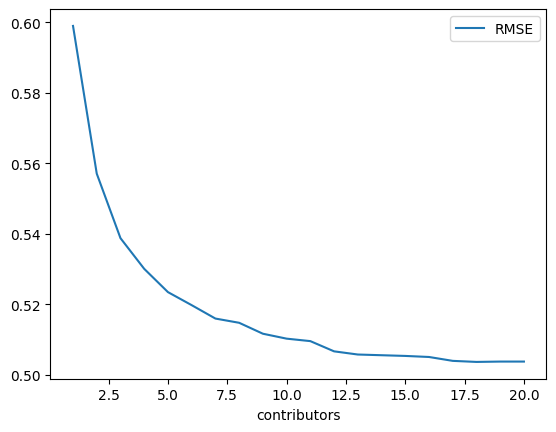

In [10]:
avg_conf = long[long.run == 'ocsai-chatgpt'].groupby('contributors', as_index=False)[['confidence']].mean()
avg_conf.contributors = avg_conf.contributors.astype(int)
#ax = avg_conf.plot(x='contributors', y='confidence', secondary_y=True, color='red', alpha=.3, style='-')

#evaluated.loc['ocsai-chatgpt'].reset_index().plot(x='contributors', y='RMSE', ax=ax)
evaluated.loc['ocsai-chatgpt'].reset_index().plot(x='contributors', y='RMSE')

## Confidence Eval

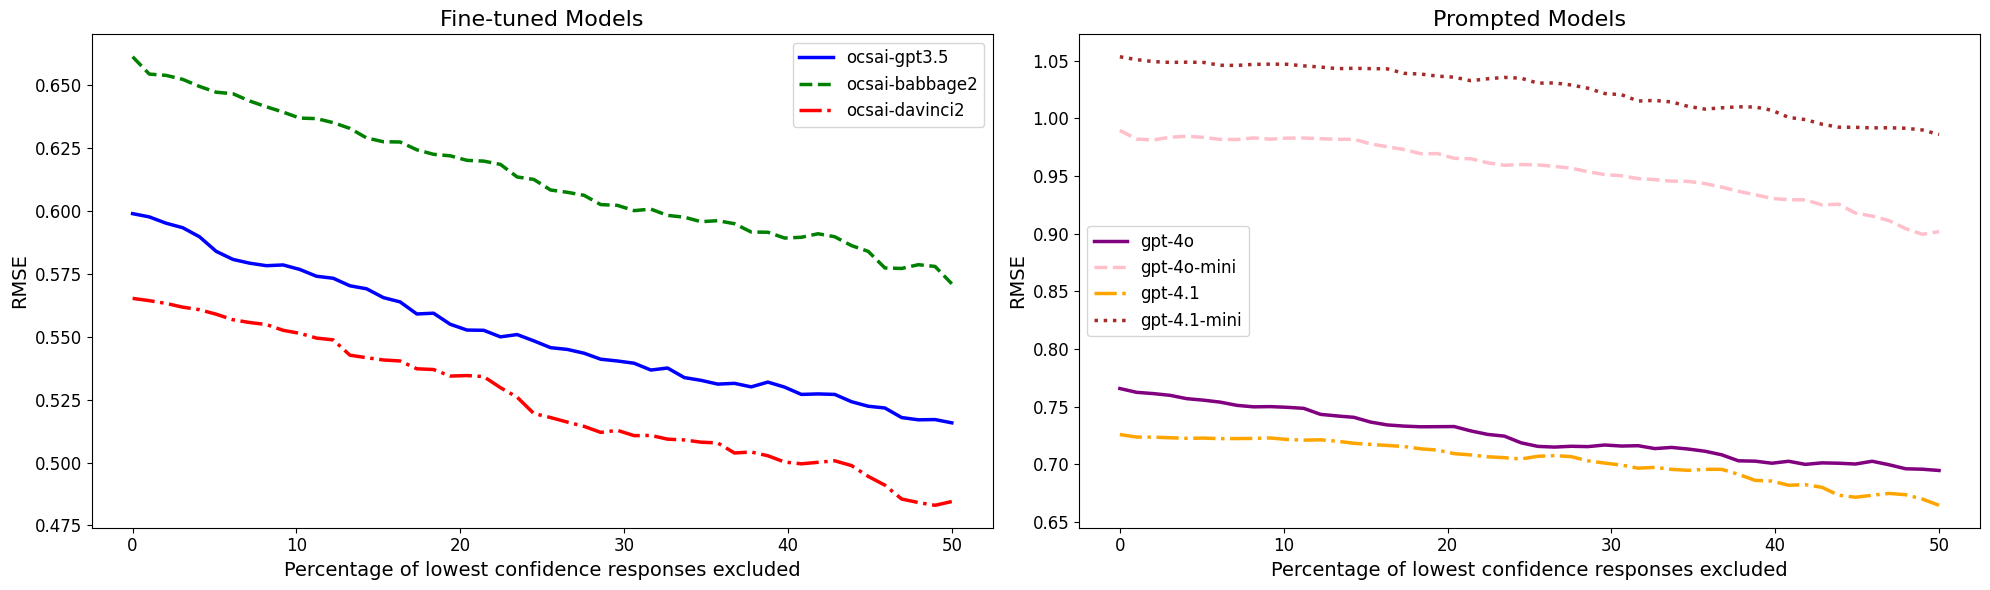

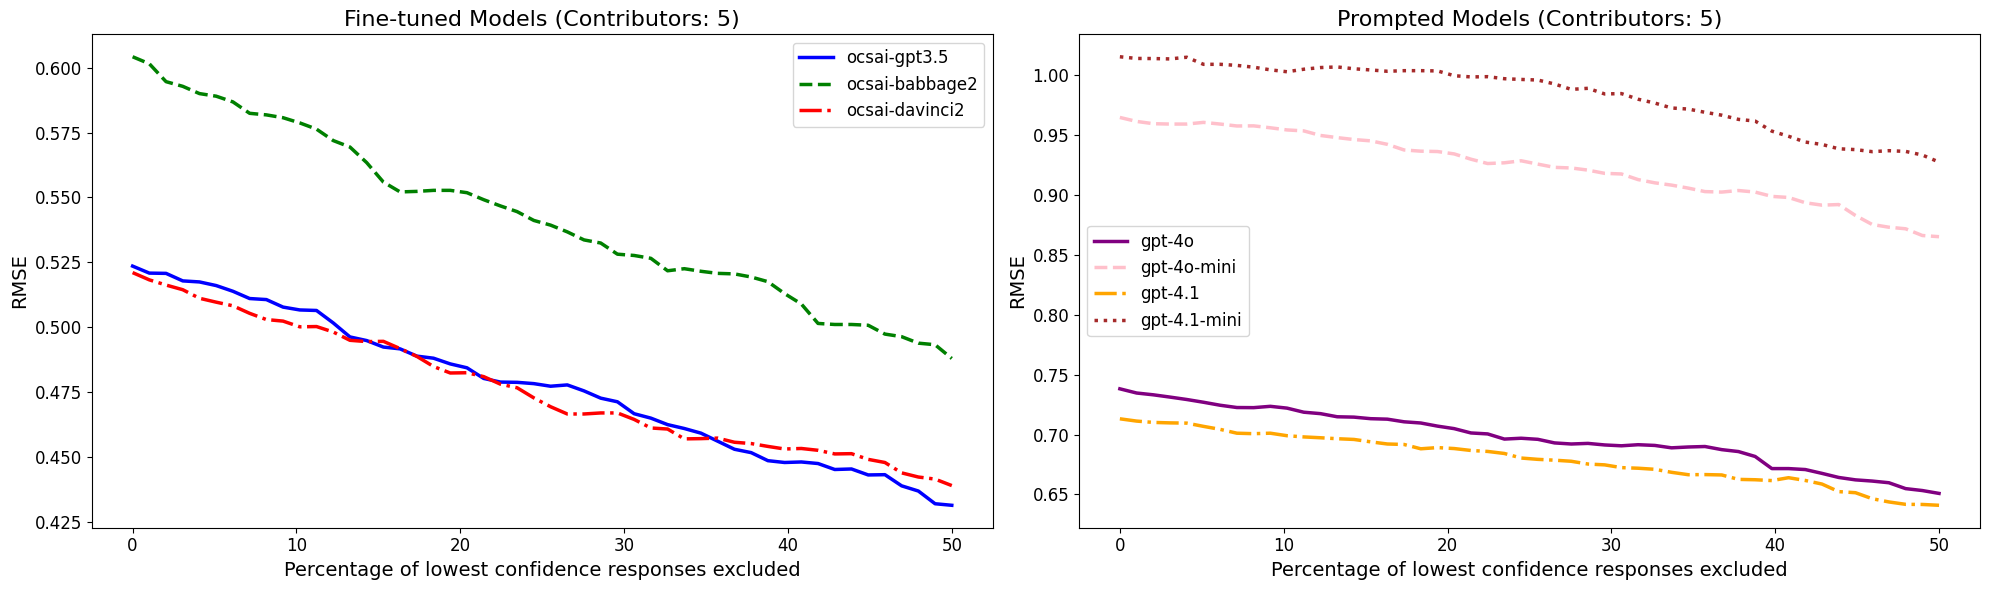

In [24]:
# Plot confidence threshold analysis for all models
n_bins = 10
top_probs = 5

# Split models into two groups
traditional_models = ['ocsai-gpt3.5', 'ocsai-babbage2', 'ocsai-davinci2']  # renamed from ocsai-chatgpt
gpt4_models = ['gpt-4o', 'gpt-4o-mini', 'gpt-4.1', 'gpt-4.1-mini']

# Line styles for black-and-white compatibility
line_styles = ['-', '--', '-.', ':']

model_groups = {
    'Fine-tuned Models': {'models': traditional_models, 'colors': ['blue', 'green', 'red']},
    'Prompted Models': {'models': gpt4_models, 'colors': ['purple', 'pink', 'orange', 'brown']}
}

# For each contributor count
for i in [1, 5]:
    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # Plot each group in its respective subplot
    for (group_name, group_info), ax in zip(model_groups.items(), [ax1, ax2]):
        # For each model in the group
        for idx, (model, color) in enumerate(zip(group_info['models'], group_info['colors'])):
            # Handle the model name replacement in the data
            data_model = 'ocsai-chatgpt' if model == 'ocsai-gpt3.5' else model
            subset = long[(long.contributors == i) & (long['run'] == data_model)].dropna().copy()
            
            # Calculate threshold performance
            rows = []
            percentiles = np.linspace(0, 50, 50)
            
            for percentile in percentiles:
                threshold = subset['confidence'].quantile(percentile/100)
                filtered_subset = subset[subset['confidence'] >= threshold]
                if len(filtered_subset) <= 100:
                    continue
                row = evaluate(filtered_subset)
                row['percentile_dropped'] = percentile
                rows.append(row)
                
            plot_df = pd.DataFrame(rows)
            # Use both color and line style for black-and-white compatibility
            style = line_styles[idx % len(line_styles)]
            ax.plot(plot_df['percentile_dropped'], plot_df['RMSE'], 
                   color=color, linestyle=style, linewidth=2.5, label=model)
        
        ax.set_xlabel("Percentage of lowest confidence responses excluded", fontsize=14)
        ax.set_ylabel("RMSE", fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=12)
        if i > 1:
            ax.set_title(f"{group_name} (Contributors: {i})", fontsize=16)
        else:
            ax.set_title(f"{group_name}", fontsize=16)
    
    plt.tight_layout()
    plt.show()

What's a reasonable number? Maybe one-fifth? If we commit to dropping the bottom fifth of auto-scored responses what is the performance (in RMSE and r, by model)?

In [44]:
# Calculate baseline and filtered metrics for comparison
results = []
for model in ['ocsai-chatgpt', 'ocsai-babbage2', 'ocsai-davinci2', 'gpt-4o', 'gpt-4o-mini', 'gpt-4.1', 'gpt-4.1-mini']:
    for i in range(1, 6):  # Looking at first 5 contributors
        subset = long[(long.contributors == i) & (long['run'] == model)].dropna().copy()
        
        # Baseline metrics (all data)
        baseline_metrics = evaluate(subset)
        baseline_metrics['model'] = model
        baseline_metrics['contributors'] = i
        baseline_metrics['filtered'] = False
        results.append(baseline_metrics)
        
        # Filtered metrics (top 80%)
        threshold = subset['confidence'].quantile(0.2)
        filtered = subset[subset['confidence'] >= threshold]
        filtered_metrics = evaluate(filtered)
        filtered_metrics['model'] = model
        filtered_metrics['contributors'] = i
        filtered_metrics['filtered'] = True
        results.append(filtered_metrics)

results = pd.DataFrame(results)

print("Single contributor performance (baseline vs dropping bottom 20%):")
display(results.query('contributors == 1')
        .drop(columns=['contributors'])
        .set_index(['model', 'filtered'])
        .sort_index())

print("\nFive contributor performance (baseline vs dropping bottom 20%):")
display(results.query('contributors == 5')
        .drop(columns=['contributors'])
        .set_index(['model', 'filtered'])
        .sort_index())

Single contributor performance (baseline vs dropping bottom 20%):


r    RMSE       n
model          filtered                       
gpt-4.1        False     0.628  0.7257  3030.0
               True      0.634  0.7122  2424.0
gpt-4.1-mini   False     0.493  1.0534  3030.0
               True      0.539  1.0366  2424.0
gpt-4o         False     0.607  0.7656  3030.0
               True      0.656  0.7329  2424.0
gpt-4o-mini    False     0.508  0.9895  3030.0
               True      0.533  0.9666  2424.0
ocsai-babbage2 False     0.722  0.6614  3030.0
               True      0.765  0.6206  2424.0
ocsai-chatgpt  False     0.781  0.5990  3030.0
               True      0.822  0.5544  2424.0
ocsai-davinci2 False     0.774  0.5653  3030.0
               True      0.809  0.5348  2424.0


Five contributor performance (baseline vs dropping bottom 20%):


r    RMSE       n
model          filtered                       
gpt-4.1        False     0.637  0.7131  3030.0
               True      0.657  0.6880  2424.0
gpt-4.1-mini   False     0.503  1.0149  3030.0
               True      0.550  1.0014  2424.0
gpt-4o         False     0.622  0.7381  3030.0
               True      0.673  0.7062  2424.0
gpt-4o-mini    False     0.520  0.9643  3030.0
               True      0.545  0.9358  2424.0
ocsai-babbage2 False     0.749  0.6042  3030.0
               True      0.795  0.5531  2424.0
ocsai-chatgpt  False     0.816  0.5235  3030.0
               True      0.846  0.4848  2424.0
ocsai-davinci2 False     0.799  0.5210  3030.0
               True      0.838  0.4821  2424.0

### Mixed-Effects Model

To account for the nested structure of responses (multiple responses per item/prompt), we fit a mixed-effects model with random intercepts for item. This addresses the non-independence of observations sharing the same prompt.

Since raw confidence values are not comparable between different contributor counts, they were normalized to a z-score. The model was statistically significant and explained 13% of the variance in absolute error. Utilizing more contributors in the score slightly but significantly reduced prediction error. Reference model is gpt-4.1.

In [46]:
# Mixed-effects model with random intercepts for item
# This accounts for the nested structure where multiple responses share the same prompt
import statsmodels.formula.api as smf

# Prepare data for mixed model (contributors == 1 for simplicity)
for_mixed = long.dropna().copy().query('contributors == 1')
for_mixed['abs_error'] = abs(for_mixed['target'] - for_mixed['score'])

print(f"Observations: {len(for_mixed)}")
print(f"Unique items: {for_mixed['item'].nunique()}")

# Fit mixed model with random intercept for item
# Formula: abs_error ~ run + confidence + (1|item)
mixed_model = smf.mixedlm(
    "abs_error ~ C(run) + confidence", 
    for_mixed,
    groups=for_mixed["item"]
)
mixed_result = mixed_model.fit(method='powell')
print("\nMixed-Effects Model (random intercept for item):")
print(mixed_result.summary())

Observations: 21210
Unique items: 21

Mixed-Effects Model (random intercept for item):
               Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    abs_error  
No. Observations:      21210      Method:                REML       
No. Groups:            21         Scale:                 0.2421     
Min. group size:       49         Log-Likelihood:        -15099.7557
Max. group size:       5397       Converged:             Yes        
Mean group size:       1010.0                                       
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 0.787    0.016  50.664 0.000  0.757  0.818
C(run)[T.gpt-4.1-mini]    0.238    0.013  18.779 0.000  0.213  0.262
C(run)[T.gpt-4o]         -0.089    0.013  -6.844 0.000 -0.115 -0.064
C(run)[T.gpt-4o-mini]     0.231 

/Users/peter.organisciak/Documents/projects/ocs/ocsai-py/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [38]:
from itertools import combinations

ensemble_model_pool = ['ocsai-babbage2', 'ocsai-davinci2', 'ocsai-chatgpt', 'gpt-4o']
ensemble_sizes = [2, 3, 5]  # pairwise + larger ensembles
max_contributors = 5
require_all_models = True

model_labels = {
    'ocsai-babbage2': 'babbage2',
    'ocsai-davinci2': 'davinci2',
    'ocsai-chatgpt': 'chatgpt',
    'gpt-4o': 'gpt4o',
    'gpt-4.1': 'gpt4.1'
}
# Reverse mapping: short name -> full name
label_to_model = {v: k for k, v in model_labels.items()}

def build_ensemble_specs(models, sizes):
    specs = {}
    for size in sizes:
        for combo in combinations(models, size):
            name = '+'.join(model_labels[m] for m in combo)
            specs[name] = list(combo)
    return specs

def build_ensemble(long_df, runs, max_contributors=5, require_all=True):
    group_cols = ['item', 'response', 'target', 'type', 'contributors']
    subset = long_df[(long_df.contributors <= max_contributors) & long_df.run.isin(runs)].copy()
    if require_all:
        counts = subset.groupby(group_cols)['run'].nunique()
        complete_keys = counts[counts == len(runs)].index
        subset = subset.set_index(group_cols).loc[complete_keys].reset_index()
    return subset.groupby(group_cols, as_index=False)[['score', 'confidence']].mean()

ensemble_specs = build_ensemble_specs(ensemble_model_pool, ensemble_sizes)

ensemble_results = []
for name, runs in ensemble_specs.items():
    ensemble_df = build_ensemble(long, runs, max_contributors=max_contributors, require_all=require_all_models)
    if ensemble_df.empty:
        continue
    metrics = ensemble_df.groupby('contributors').apply(evaluate).reset_index()
    metrics['model'] = name
    metrics['models_list'] = [runs] * len(metrics)  # Store full model names for lookup
    ensemble_results.append(metrics)

ensemble_results = pd.concat(ensemble_results, ignore_index=True)

# Add columns for difference from average of individual models
def calc_avg_individual_perf(row):
    """Calculate average RMSE and r of the individual models in this ensemble."""
    models = row['models_list']
    contrib = row['contributors']
    
    rmses = []
    rs = []
    for model in models:
        try:
            model_perf = evaluated.loc[(model, contrib)]
            rmses.append(model_perf['RMSE'])
            rs.append(model_perf['r'])
        except KeyError:
            continue
    
    if rmses and rs:
        return pd.Series({
            'avg_ind_RMSE': np.mean(rmses),
            'avg_ind_r': np.mean(rs)
        })
    return pd.Series({'avg_ind_RMSE': np.nan, 'avg_ind_r': np.nan})

# Calculate average individual performance and differences
avg_perf = ensemble_results.apply(calc_avg_individual_perf, axis=1)
ensemble_results['avg_ind_RMSE'] = avg_perf['avg_ind_RMSE']
ensemble_results['avg_ind_r'] = avg_perf['avg_ind_r']

# Difference columns: negative RMSE_diff means ensemble is better (lower RMSE)
# positive r_diff means ensemble is better (higher r)
ensemble_results['RMSE_diff'] = (ensemble_results['RMSE'] - ensemble_results['avg_ind_RMSE']).round(4)
ensemble_results['r_diff'] = (ensemble_results['r'] - ensemble_results['avg_ind_r']).round(3)

/var/folders/k2/vg86l2h54czgjfzlmd6fkz908bdx0t/T/ipykernel_42685/2131787011.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = ensemble_df.groupby('contributors').apply(evaluate).reset_index()
/var/folders/k2/vg86l2h54czgjfzlmd6fkz908bdx0t/T/ipykernel_42685/2131787011.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = ensemble_df.groupby('contributors').apply(evaluate).reset_index()


In [42]:
# this list of all permultations is too big for meaningful analysis, so not adding to paper.
# - but here's a sample
# the 'avg_' is the average of the individual models
ensemble_results.sort_values(['contributors', 'RMSE'])[['contributors', 'model', 'r', 'RMSE', 'avg_ind_r', 'avg_ind_RMSE', 'r_diff', 'RMSE_diff']].sample(5)

,contributors,model,r,RMSE,avg_ind_r,avg_ind_RMSE,r_diff,RMSE_diff
35,1,babbage2+davinci2+gpt4o,0.791,0.5362,0.701000,0.6641,0.090,-0.1279
45,1,davinci2+chatgpt+gpt4o,0.797,0.5306,0.720667,0.6433,0.076,-0.1127
33,4,babbage2+davinci2+chatgpt,0.816,0.5131,0.786000,0.5546,0.030,-0.0415
8,4,babbage2+chatgpt,0.806,0.5353,0.780000,0.5700,0.026,-0.0347
26,2,chatgpt+gpt4o,0.772,0.5615,0.709500,0.6534,0.062,-0.0919


In [39]:
single_models = results.query('contributors == 5').query('filtered == False').drop(columns=['filtered'])[ensemble_results.columns.intersection(results.columns)]
x = ensemble_results.query('contributors == 5').rename(columns={'ensemble': 'R'})
pd.concat([single_models, x]).drop(columns=['contributors', 'n']).sort_values(['RMSE'])

,r,RMSE,model,models_list,avg_ind_RMSE,avg_ind_r,RMSE_diff,r_diff
19,0.823,0.4978,davinci2+chatgpt,"[ocsai-davinci2, ocsai-chatgpt]",0.522250,0.807500,-0.0244,0.015
49,0.809,0.5068,davinci2+chatgpt+gpt4o,"[ocsai-davinci2, ocsai-chatgpt, gpt-4o]",0.594200,0.745667,-0.0874,0.063
34,0.817,0.5090,babbage2+davinci2+chatgpt,"[ocsai-babbage2, ocsai-davinci2, ocsai-chatgpt]",0.549567,0.788000,-0.0406,0.029
44,0.807,0.5135,babbage2+chatgpt+gpt4o,"[ocsai-babbage2, ocsai-chatgpt, gpt-4o]",0.621933,0.729000,-0.1084,0.078
39,0.803,0.5155,babbage2+davinci2+gpt4o,"[ocsai-babbage2, ocsai-davinci2, gpt-4o]",0.621100,0.723333,-0.1056,0.080
28,0.799,0.5210,ocsai-davinci2,NaN,NaN,NaN,NaN,NaN
8,0.816,0.5235,ocsai-chatgpt,NaN,NaN,NaN,NaN,NaN
9,0.808,0.5296,babbage2+chatgpt,"[ocsai-babbage2, ocsai-chatgpt]",0.563850,0.782500,-0.0342,0.026
4,0.798,0.5313,babbage2+davinci2,"[ocsai-babbage2, ocsai-davinci2]",0.562600,0.774000,-0.0313,0.024
29,0.779,0.5480,chatgpt+gpt4o,"[ocsai-chatgpt, gpt-4o]",0.630800,0.719000,-0.0828,0.060


## Model Confidence vs Human Disagreement

This analysis addresses the reviewer question: Do items with high human disagreement (high rating_std) correspond to low model confidence?

We'll load the human rating variance data from ocsai-all.csv and compare it with the log probability-based confidence scores.

In [ ]:
# Load human rating variance data
ocsai_all = pd.read_csv(data_dir / 'ocsai-all.csv')

# Filter to only English uses (to match our test data)
ocsai_all_eng_uses = ocsai_all[(ocsai_all['language'] == 'eng') & (ocsai_all['type'] == 'uses')].copy()

# Keep only relevant columns
ocsai_all_eng_uses = ocsai_all_eng_uses[['prompt', 'response', 'target', 'rating_std']].drop_duplicates()

print(f"Loaded {len(ocsai_all_eng_uses)} unique responses with human variance data")
print(f"Rating std range: {ocsai_all_eng_uses['rating_std'].min():.2f} to {ocsai_all_eng_uses['rating_std'].max():.2f}")
print(f"Mean rating std: {ocsai_all_eng_uses['rating_std'].mean():.2f}")
ocsai_all_eng_uses.head()

In [ ]:
# Merge with model confidence data
# Use the 'long' dataframe which has all models and contributors
long_with_human_var = long.merge(
    ocsai_all_eng_uses[['prompt', 'response', 'rating_std']],
    left_on=['item', 'response'],
    right_on=['prompt', 'response'],
    how='left'
)

# Check merge success
print(f"Rows with human variance data: {long_with_human_var['rating_std'].notna().sum()} / {len(long_with_human_var)}")
print(f"Percentage matched: {100 * long_with_human_var['rating_std'].notna().sum() / len(long_with_human_var):.1f}%")

# Show sample
long_with_human_var[long_with_human_var['rating_std'].notna()].sample(5)[['run', 'item', 'response', 'target', 'contributors', 'score', 'confidence', 'rating_std']]

### Correlation Analysis: Model Confidence vs Human Disagreement

For each model, calculate the correlation between model confidence and human rating_std.

In [25]:
# Calculate correlation between model confidence and human rating_std
# Do this for each model and contributor level
correlations = []

for model in ['ocsai-chatgpt', 'ocsai-davinci2', 'gpt-4o']:
    for contrib in [1, 5]:
        subset = long_with_human_var[
            (long_with_human_var['run'] == model) & 
            (long_with_human_var['contributors'] == contrib) &
            (long_with_human_var['rating_std'].notna())
        ].copy()
        
        if len(subset) > 100:  # Need enough data
            # Correlation between model confidence and human disagreement (rating_std)
            corr, p_val = pearsonr(subset['confidence'], subset['rating_std'])
            correlations.append({
                'model': model,
                'contributors': contrib,
                'correlation': np.round(corr, 3),
                'p_value': np.round(p_val, 5),
                'n': len(subset)
            })

corr_df = pd.DataFrame(correlations)
print("Correlation between model confidence and human rating_std:")
print("(Negative = model is less confident when humans disagree)")
display(corr_df.pivot(index='contributors', columns='model', values='correlation'))

Correlation between model confidence and human rating_std:
(Negative = model is less confident when humans disagree)


model,gpt-4o,ocsai-chatgpt,ocsai-davinci2
contributors,,,
1,-0.307,-0.379,-0.339
5,-0.330,-0.364,-0.302


### Cross-tabulation: High/Low Model Confidence vs High/Low Human Disagreement

In [21]:
# Create binary categories for model confidence and human disagreement
# Use median split for both

for model in ['ocsai-chatgpt']:
    print(f"\n{'='*60}")
    print(f"Model: {model}")
    print('='*60)
    
    for contrib in [1]:
        subset = long_with_human_var[
            (long_with_human_var['run'] == model) & 
            (long_with_human_var['contributors'] == contrib) &
            (long_with_human_var['rating_std'].notna())
        ].copy()
        
        if len(subset) < 100:
            continue
            
        # Binary splits at median
        subset['high_model_confidence'] = subset['confidence'] >= subset['confidence'].median()
        subset['high_human_disagreement'] = subset['rating_std'] >= subset['rating_std'].median()
        
        # Create crosstab
        crosstab = pd.crosstab(
            subset['high_model_confidence'], 
            subset['high_human_disagreement'],
            normalize='all'
        ) * 100  # Convert to percentages
        
        crosstab.index = ['Low Model Conf', 'High Model Conf']
        crosstab.columns = ['Low Human Disagree', 'High Human Disagree']
        
        print(f"\nContributors: {contrib}")
        print("Percentage of responses in each category:")
        display(crosstab.round(1))
        
        # Show performance metrics for each quadrant
        print("\nRMSE by quadrant:")
        rmse_by_quadrant = subset.groupby(['high_model_confidence', 'high_human_disagreement']).apply(
            lambda x: np.sqrt(mean_squared_error(x['target'], x['score']))
        ).round(3)
        rmse_by_quadrant.index = pd.MultiIndex.from_tuples(
            [('Low Model Conf' if not x else 'High Model Conf', 
              'Low Human Disagree' if not y else 'High Human Disagree') 
             for x, y in rmse_by_quadrant.index]
        )
        display(rmse_by_quadrant)


Model: ocsai-chatgpt

Contributors: 1
Percentage of responses in each category:


,Low Human Disagree,High Human Disagree
Low Model Conf,13.1,36.9
High Model Conf,22.2,27.8



RMSE by quadrant:


Low Model Conf   Low Human Disagree     0.643
                 High Human Disagree    0.696
High Model Conf  Low Human Disagree     0.418
                 High Human Disagree    0.583
dtype: float64